<a href="https://colab.research.google.com/github/GuillenConcepcion/Lab_GC/blob/main/MLOps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLOps in Enterprise Organizations: From Chaos to Control Using MLflow in Google Colab

https://drlee.io/mlops-in-enterprise-organizations-from-chaos-to-control-using-mlflow-in-google-colab-592edbdabbe1

###
La transformación de "científico de datos que crea un modelo" a "empresa que implementa IA a escala" no se trata de mejores algoritmos. Se trata de implementar MLOps: el enfoque sistemático para versionar, rastrear e implementar modelos de aprendizaje automático con el mismo rigor que aplicarías al software de producción. En los próximos diez minutos, crearás un sistema completo de seguimiento de MLflow íntegramente en Google Colab : sin servidores que aprovisionar, sin infraestructura que administrar, solo un entorno gratuito basado en navegador que captura cada iteración del modelo, cada cambio de parámetro y cada métrica de rendimiento.
###

1. Installed MLflow with a single command (no dependency conflicts or environment setup)
2. Launched a professional MLflow tracking server (normally requires Docker, cloud VMs, or Kubernetes)
3. Versioned and logged a machine learning model with full parameter and metric tracking
4. Accessed a production-grade UI for comparing experiments and analyzing results
5. Demonstrated model loading and inference using MLflow’s deployment patterns

# Step 1: Environment Setup and MLflow Installation in Colab

In [1]:
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.1/329.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.4/718.4 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.6/106.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5

In [3]:
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import mlflow
from mlflow.models import infer_signature

In [4]:
!nohup mlflow server --host 127.0.0.1 --port 5051 > mlflow.log 2>&1 &--host 127.0.0.1 --port 5051 > mlflow.log 2>&1 &

In [6]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:5051")

# Step 3: Data Preparation and Model Training

Load the Iris dataset and split it into training and test sets:

In [8]:
X, y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
params = {
      "solver": "lbfgs",
      "max_iter": 1000,
      "multi_class": "auto",
      "random_state": 8888
  }

In [10]:
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto', random_state=8888)

In [12]:
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 1.0000


# Step 4: Creating Your First Tracked Experiment

In [14]:
mlflow.set_experiment("MLflow Part 1")

2025/10/02 18:35:52 INFO mlflow.tracking.fluent: Experiment with name 'MLflow Part 1' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/382534123125634824', creation_time=1759430152569, experiment_id='382534123125634824', last_update_time=1759430152569, lifecycle_stage='active', name='MLflow Part 1', tags={}>

In [15]:
with mlflow.start_run():
      # Log the hyperparameters
      mlflow.log_params(params)

      # Log the accuracy metric
      mlflow.log_metric("accuracy", accuracy)

      # Add a descriptive tag for context
      mlflow.set_tag("Training Info", "Basic LR model for iris data")

      # Infer the model signature (input/output schema)
      signature = infer_signature(X_train, lr.predict(X_train))

      # Log the trained model to the registry
      model_info = mlflow.sklearn.log_model(
          sk_model=lr,
          artifact_path="iris_model",
          signature=signature,
          input_example=X_train,
          registered_model_name="tracking-quickstart"
      )

2025/10/02 18:36:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'tracking-quickstart'.
2025/10/02 18:36:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: tracking-quickstart, version 1
Created version '1' of model 'tracking-quickstart'.


🏃 View run thundering-stoat-416 at: http://127.0.0.1:5051/#/experiments/382534123125634824/runs/5fab7b21cbbb458299b92ab09e9f137f
🧪 View experiment at: http://127.0.0.1:5051/#/experiments/382534123125634824


# Step 5: Accessing the MLflow UI in Google Colab

In [16]:
from google.colab import output
output.serve_kernel_port_as_window(5051)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

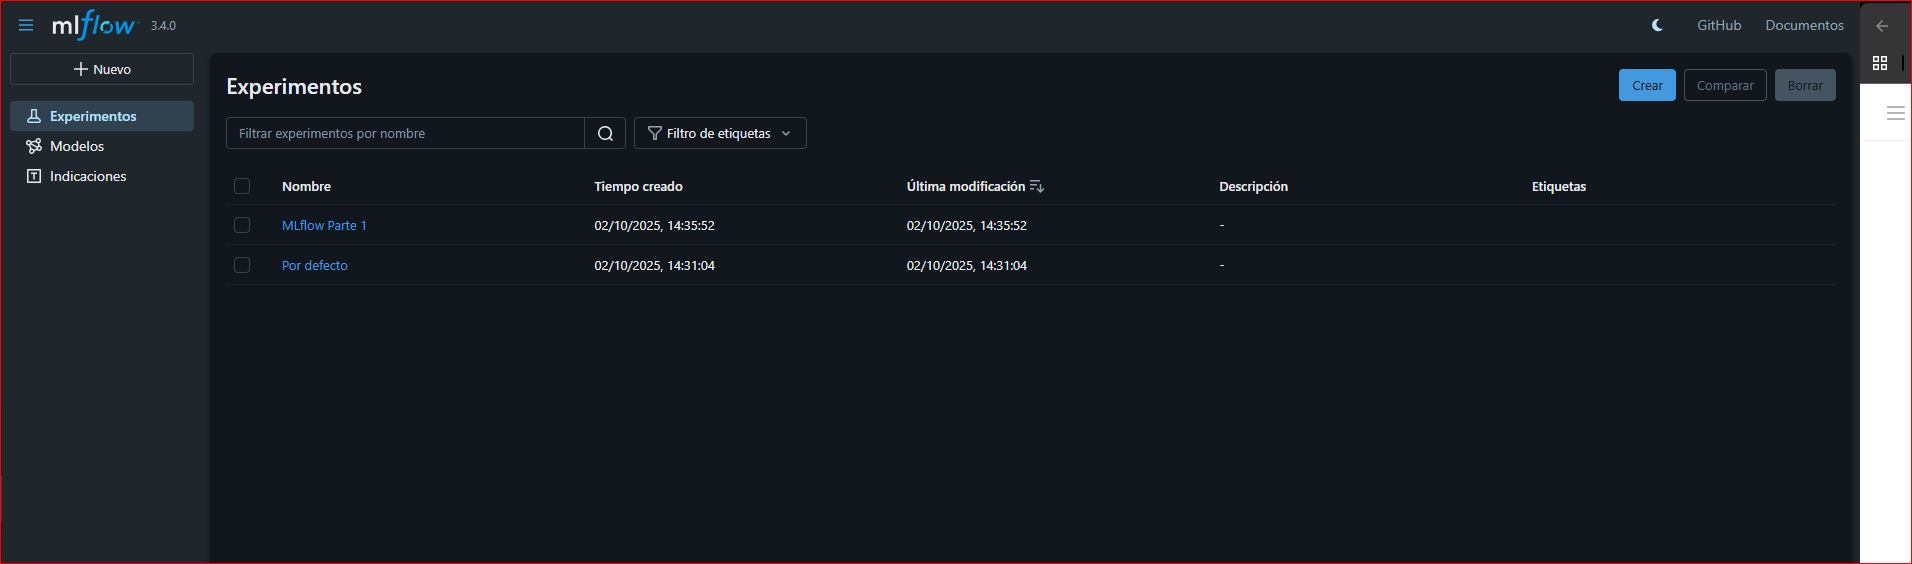

# Step 6: Loading and Using Your Tracked Model


In [18]:
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

## Generate predictions using the loaded model:

In [19]:
predictions = loaded_model.predict(X_test)

## Create a results DataFrame to compare predictions against actual values:

In [21]:
iris_feature_names = datasets.load_iris().feature_names
result = pd.DataFrame(X_test, columns=iris_feature_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions
print(result[:4])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                6.1               2.8                4.7               1.2   
1                5.7               3.8                1.7               0.3   
2                7.7               2.6                6.9               2.3   
3                6.0               2.9                4.5               1.5   

   actual_class  predicted_class  
0             1                1  
1             0                0  
2             2                2  
3             1                1  
